In [16]:
import pandas as pd

df = pd.read_csv("data/stocks/TSLA.csv")  # use any one stock
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [17]:
# Daily Return
df['Daily_Return'] = df['Adj Close'].pct_change()

# Target for future prediction
df['Target_Next_Day_Close'] = df['Adj Close'].shift(-1)

# Drop NaN values
df = df.dropna()

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target_Next_Day_Close
1,2010-06-30,25.790001,30.420000,23.299999,23.830000,23.830000,17187100,-0.002511,21.959999
2,2010-07-01,25.000000,25.920000,20.270000,21.959999,21.959999,8218800,-0.078473,19.200001
3,2010-07-02,23.000000,23.100000,18.709999,19.200001,19.200001,5139800,-0.125683,16.110001
4,2010-07-06,20.000000,20.000000,15.830000,16.110001,16.110001,6866900,-0.160938,15.800000
5,2010-07-07,16.400000,16.629999,14.980000,15.800000,15.800000,6921700,-0.019243,17.459999


In [18]:
print("Descriptive Statistics:\n")
print(df[['Volume', 'Daily_Return']].describe())

print("\nVariance:\n")
print(df[['Volume', 'Daily_Return']].var())

Descriptive Statistics:

             Volume  Daily_Return
count  2.455000e+03   2455.000000
mean   5.821561e+06      0.001837
std    5.466792e+06      0.034143
min    1.185000e+05     -0.193274
25%    1.960350e+06     -0.014632
50%    4.668100e+06      0.000845
75%    7.522100e+06      0.018152
max    6.093880e+07      0.243951

Variance:

Volume          2.988582e+13
Daily_Return    1.165776e-03
dtype: float64


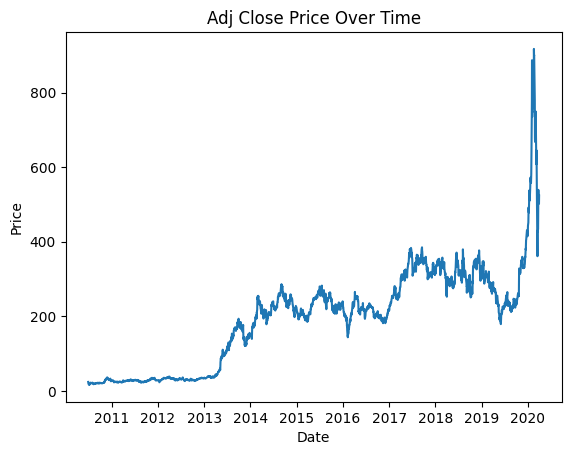

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['Date'], df['Adj Close'])
plt.title("Adj Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [20]:
df['Volatility'] = df['Daily_Return'].rolling(7).std()

In [21]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    up_days['Volume'],
    down_days['Volume'],
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: 1.9733350066613669
P-value: 0.04848648579263966


Null Hypothesis (H0): The mean trading volume on up days is equal to that on down days.

Alternative Hypothesis (H1): The mean trading volume on up days is different from that on down days.

Decision Rule:
If p-value < 0.05, reject H0; otherwise, fail to reject H0.

Conclusion:
Based on the computed p-value, we determine whether trading volume differs significantly between up and down days.